In [99]:
# Python implementation of Artificial Neural Network (ANN)
# Dr. G. Pang, August 2025

In [100]:
import numpy as np
import copy

In [101]:
def sigmoid(x):
    """Sigmoid activation function."""
    return 1.0 / (1.0 + np.exp(-x))

In [105]:
def bp_logsig_lin(inputs, outputs, num_hid, alpha, beta, err, max_stop):
    """
    Backpropagation Algorithm for an ANN with one hidden layer
    LOGSIG function is used in hidden layer; 
    LINEAR function is used in output layer.

    Args:
        inputs (numpy.ndarray): Input matrix of shape (samples, n).
        outputs (numpy.ndarray): Output matrix of shape (samples, q).
        num_hid (int): Number of hidden units (i.e., p).
        alpha (float): Learning rate between the output and hidden layer.
        beta (float): Learning rate between the input and hidden layer.
        err (float): Error for the stopping criterion.
        max_stop (int): Maximum number of iterations.

    Returns:
        tuple: (convergence, ave_err, max_err, result, v, w, thres_b, thres_c)
    """
    print("Demo on Backpropagation Algorithm by Dr. G. Pang")

    # Dimensions of input and output matrices
    num_examples, num_in = inputs.shape
    _, num_out = outputs.shape
    
    print('number of training samples = ', num_examples)
    print('number of input = ', num_in)
    print('number of output = ', num_out)

    if num_examples != outputs.shape[0]:
        raise ValueError("Number of input-output training examples not the same")

    # Initialize convergence vector
    convergence = np.zeros(max_stop)

    # Initialize weights and thresholds randomly
    v = np.random.rand(num_in, num_hid) - 0.5*np.ones((num_in, num_hid))
    w = np.random.rand(num_hid, num_out) - 0.5*np.ones((num_hid, num_out))
    thres_b = np.random.rand(1, num_hid) - 0.5*np.ones((1, num_hid))
    thres_c = np.random.rand(1, num_out) - 0.5*np.ones((1, num_out))

    # Initialize variables
    iterations = 0
    max_err = 1000

    # Main training loop
    while max_err >= err and iterations < max_stop:
        iterations += 1

        for n in range(num_examples):
            # Forward pass
            a = inputs[n, :]
            ck = outputs[n, :]

            # Hidden layer outputs
            b = sigmoid(np.dot(a, v) + thres_b)

            # Output layer outputs
            c = np.dot(b, w) + thres_c

            # Compute errors at the output
            d = ck - c

            # Compute errors at the hidden layer
            e = b * (1 - b) * np.dot(d, w.T)

            # Update weights and thresholds
            w += alpha * np.outer(b, d)
            thres_c += alpha * d

            v += beta * np.outer(a, e)
            thres_b += beta * e

        # Recall phase
        save_err = np.zeros((num_examples, num_out))
        for n in range(num_examples):
            a = inputs[n, :]
            ck = outputs[n, :]

            # Hidden layer outputs
            b = sigmoid(np.dot(a, v) + thres_b)

            # Output layer outputs
            c = np.dot(b, w) + thres_c
            save_err[n, :] = np.abs(ck - c)

        # Calculate average and maximum errors
        ave_err = np.sum(save_err) / (num_examples * num_out)
        max_err = np.max(save_err)

        print(f"Iteration: {iterations}, Average Error: {ave_err}, Max Error: {max_err}")
        convergence[iterations - 1] = ave_err

    print("Stopping criterion has been reached!")
    print("The results after training: inputs, desired outputs, NN outputs")

    # Final recall
    result = np.zeros((num_examples, num_out))
    for n in range(num_examples):
        a = inputs[n, :]
        b = sigmoid(np.dot(a, v) + thres_b)
        result[n, :] = np.dot(b, w) + thres_c

    return convergence, ave_err, max_err, result, v, w, thres_b, thres_c

In [74]:
P = np.linspace(-1,1,21)
print(P.shape)

T=np.array([-0.96, -0.577,  -0.0729,  0.377,  0.641,
            0.66 , 0.461 , 0.1336 , -0.201,  -0.434,
            -0.5 , -0.393,  -0.1647, 0.0988, 0.3072,
            0.396 ,0.3449 , 0.1816,  -0.0312,  -0.2189, -0.3201])

(21,)


In [75]:
# parameters
num_hid = 5
alpha = 0.3
beta = 0.3
err = 0.005 
max_stop = 2000
inputs = copy.deepcopy(P)
outputs = copy.deepcopy(T)
inputs = inputs.reshape(21,1)
outputs = outputs.reshape(21,1)

In [76]:
convergence, ave_err, max_err, result, v, w, thres_b, thres_c = bp_logsig_lin(
    inputs, outputs, num_hid, alpha, beta, err, max_stop)

Demo on Backpropagation Algorithm by Dr. G. Pang
number of training samples =  21
number of input =  1
number of output =  1
Iteration: 1, Average Error: 0.3994288464436024, Max Error: 0.887004049747115
Iteration: 2, Average Error: 0.3970350484189459, Max Error: 0.8768136987275796
Iteration: 3, Average Error: 0.3946525717057752, Max Error: 0.8666633544953395
Iteration: 4, Average Error: 0.39227473472137686, Max Error: 0.8565248365470888
Iteration: 5, Average Error: 0.3898970792622066, Max Error: 0.846380171136049
Iteration: 6, Average Error: 0.38775847788772616, Max Error: 0.8362207195028906
Iteration: 7, Average Error: 0.3861528422107945, Max Error: 0.8344095830075167
Iteration: 8, Average Error: 0.3845462786829141, Max Error: 0.8478270822490297
Iteration: 9, Average Error: 0.38294032911162634, Max Error: 0.8612037305728815
Iteration: 10, Average Error: 0.3813373318724937, Max Error: 0.8745089525215869
Iteration: 11, Average Error: 0.37974027524255227, Max Error: 0.8877062614765519
It

Iteration: 144, Average Error: 0.36030655054407335, Max Error: 1.0987876298029966
Iteration: 145, Average Error: 0.36023366465891166, Max Error: 1.0985551001463176
Iteration: 146, Average Error: 0.3601608990099828, Max Error: 1.0983220108241347
Iteration: 147, Average Error: 0.3600882446462043, Max Error: 1.0980882850901412
Iteration: 148, Average Error: 0.3600156927016933, Max Error: 1.0978538461091905
Iteration: 149, Average Error: 0.35994323439193543, Max Error: 1.0976186169634732
Iteration: 150, Average Error: 0.35987086101000465, Max Error: 1.0973825206573142
Iteration: 151, Average Error: 0.3597985639228378, Max Error: 1.0971454801207283
Iteration: 152, Average Error: 0.3597263345675697, Max Error: 1.0969074182118592
Iteration: 153, Average Error: 0.3596541644479297, Max Error: 1.0966682577184197
Iteration: 154, Average Error: 0.35958204513070585, Max Error: 1.096427921358247
Iteration: 155, Average Error: 0.3595099682422771, Max Error: 1.09618633177907
Iteration: 156, Average Er

Iteration: 328, Average Error: 0.34082598529735836, Max Error: 0.9712727349496233
Iteration: 329, Average Error: 0.34065074187991573, Max Error: 0.969863617123655
Iteration: 330, Average Error: 0.3404747125865275, Max Error: 0.9684491052206357
Iteration: 331, Average Error: 0.3402979101937054, Max Error: 0.9670293871959139
Iteration: 332, Average Error: 0.3401203479189065, Max Error: 0.96560465488122
Iteration: 333, Average Error: 0.33994203941880263, Max Error: 0.9641751039167921
Iteration: 334, Average Error: 0.3397629987870738, Max Error: 0.9627409336781487
Iteration: 335, Average Error: 0.3395832405517135, Max Error: 0.9613023471974983
Iteration: 336, Average Error: 0.33940277967184196, Max Error: 0.9598595510797772
Iteration: 337, Average Error: 0.33922163153401863, Max Error: 0.9584127554133204
Iteration: 338, Average Error: 0.3390398119480465, Max Error: 0.956962173675189
Iteration: 339, Average Error: 0.3388573371422665, Max Error: 0.9555080226311832
Iteration: 340, Average Err

Iteration: 516, Average Error: 0.32286482064110317, Max Error: 0.794663186173176
Iteration: 517, Average Error: 0.3228199329494912, Max Error: 0.7944473138495052
Iteration: 518, Average Error: 0.32277502391264534, Max Error: 0.7942355745447266
Iteration: 519, Average Error: 0.3227300954937175, Max Error: 0.7940279020662825
Iteration: 520, Average Error: 0.32268514958505956, Max Error: 0.7938242311326833
Iteration: 521, Average Error: 0.3226401880097026, Max Error: 0.7936244973695271
Iteration: 522, Average Error: 0.32259521252281953, Max Error: 0.7934286373050558
Iteration: 523, Average Error: 0.3225502248131709, Max Error: 0.7932365883652772
Iteration: 524, Average Error: 0.3225052265045312, Max Error: 0.7930482888686725
Iteration: 525, Average Error: 0.3224602191570981, Max Error: 0.7928636780205244
Iteration: 526, Average Error: 0.3224152042688829, Max Error: 0.792682695906876
Iteration: 527, Average Error: 0.3223701832770803, Max Error: 0.7925052834881468
Iteration: 528, Average Er

Iteration: 696, Average Error: 0.3187607622668629, Max Error: 0.7862057446203028
Iteration: 697, Average Error: 0.3187311840606646, Max Error: 0.786218692217497
Iteration: 698, Average Error: 0.31870148569644124, Max Error: 0.7862316366662656
Iteration: 699, Average Error: 0.31867166649653267, Max Error: 0.786244571395688
Iteration: 700, Average Error: 0.3186417257779208, Max Error: 0.786257489866951
Iteration: 701, Average Error: 0.3186116628521911, Max Error: 0.7862703855723601
Iteration: 702, Average Error: 0.3185814770254934, Max Error: 0.7862832520343588
Iteration: 703, Average Error: 0.31855116759849933, Max Error: 0.7862960828045636
Iteration: 704, Average Error: 0.31852073386635926, Max Error: 0.7863088714628022
Iteration: 705, Average Error: 0.3184901751186544, Max Error: 0.7863216116161666
Iteration: 706, Average Error: 0.31845949063934975, Max Error: 0.7863342968980713
Iteration: 707, Average Error: 0.31842867970674194, Max Error: 0.786346920967328
Iteration: 708, Average Er

...

Iteration: 1258, Average Error: 0.234906377305352, Max Error: 1.2202424723010448
Iteration: 1259, Average Error: 0.2345352042270043, Max Error: 1.221600315318868
Iteration: 1260, Average Error: 0.23416464079291033, Max Error: 1.2229394128981963
Iteration: 1261, Average Error: 0.23379470071784395, Max Error: 1.2242600170351556
Iteration: 1262, Average Error: 0.23342539808430365, Max Error: 1.2255623666897912
Iteration: 1263, Average Error: 0.2330567474004473, Max Error: 1.2268466884072533
Iteration: 1264, Average Error: 0.23268876365130234, Max Error: 1.2281131969455048
Iteration: 1265, Average Error: 0.23232146234336973, Max Error: 1.229362095906668
Iteration: 1266, Average Error: 0.231954859542746, Max Error: 1.230593578369297
Iteration: 1267, Average Error: 0.23158897190692448, Max Error: 1.2318078275190638
Iteration: 1268, Average Error: 0.23122381671043443, Max Error: 1.2330050172755052
Iteration: 1269, Average Error: 0.23090913490926276, Max Error: 1.2341853129126559
Iteration: 12

Iteration: 1431, Average Error: 0.20719226649793981, Max Error: 1.292114744543213
Iteration: 1432, Average Error: 0.20711925081338398, Max Error: 1.2921362232080467
Iteration: 1433, Average Error: 0.20704621710017218, Max Error: 1.292157023150477
Iteration: 1434, Average Error: 0.20697316532792673, Max Error: 1.2921771603821748
Iteration: 1435, Average Error: 0.20690009549596336, Max Error: 1.292196650326026
Iteration: 1436, Average Error: 0.20682700763261808, Max Error: 1.2922155078311826
Iteration: 1437, Average Error: 0.20675390179456407, Max Error: 1.2922337471877814
Iteration: 1438, Average Error: 0.20668077806612095, Max Error: 1.2922513821413348
Iteration: 1439, Average Error: 0.20660763655855938, Max Error: 1.2922684259067925
Iteration: 1440, Average Error: 0.20653447740939682, Max Error: 1.2922848911822888
Iteration: 1441, Average Error: 0.20646130078169217, Max Error: 1.2923007901625736
Iteration: 1442, Average Error: 0.2063881068633335, Max Error: 1.292316134552137
Iteration

Iteration: 1613, Average Error: 0.19575429200560837, Max Error: 1.2877087198852297
Iteration: 1614, Average Error: 0.19569209959144077, Max Error: 1.2876150640092425
Iteration: 1615, Average Error: 0.19562979268554906, Max Error: 1.2875200111507166
Iteration: 1616, Average Error: 0.19556736873765224, Max Error: 1.2874235406993897
Iteration: 1617, Average Error: 0.1955048251359218, Max Error: 1.2873256316014827
Iteration: 1618, Average Error: 0.19544215920546965, Max Error: 1.2872262623475388
Iteration: 1619, Average Error: 0.19537936820678578, Max Error: 1.2871254109598849
Iteration: 1620, Average Error: 0.19531644933412592, Max Error: 1.287023054979737
Iteration: 1621, Average Error: 0.1952533997138437, Max Error: 1.2869191714538881
Iteration: 1622, Average Error: 0.19519021640266881, Max Error: 1.2868137369209982
Iteration: 1623, Average Error: 0.19512689638592698, Max Error: 1.2867067273974748
Iteration: 1624, Average Error: 0.19506343657570008, Max Error: 1.2865981183628998
Iterati

Iteration: 1802, Average Error: 0.1722494004087073, Max Error: 1.1057400497780194
Iteration: 1803, Average Error: 0.17164574243774391, Max Error: 1.101511758815088
Iteration: 1804, Average Error: 0.17102681312706766, Max Error: 1.0972144643055435
Iteration: 1805, Average Error: 0.17039280106401988, Max Error: 1.092849337245907
Iteration: 1806, Average Error: 0.16974392756181747, Max Error: 1.0884176580628275
Iteration: 1807, Average Error: 0.1690956969181984, Max Error: 1.0839208101950908
Iteration: 1808, Average Error: 0.1684410266474365, Max Error: 1.079360272980037
Iteration: 1809, Average Error: 0.16786283012306447, Max Error: 1.0747376140037905
Iteration: 1810, Average Error: 0.16733204771408988, Max Error: 1.070054481090954
Iteration: 1811, Average Error: 0.1667881204075249, Max Error: 1.0653125941190127
Iteration: 1812, Average Error: 0.1662309262674944, Max Error: 1.0605137368447328
Iteration: 1813, Average Error: 0.16573529679411567, Max Error: 1.0556597489240058
Iteration: 18

Iteration: 1987, Average Error: 0.04444362128414351, Max Error: 0.2365407428651498
Iteration: 1988, Average Error: 0.04406521326798065, Max Error: 0.2335477362392493
Iteration: 1989, Average Error: 0.043690305026628504, Max Error: 0.23058472468292268
Iteration: 1990, Average Error: 0.04331888132241436, Max Error: 0.22765158398789764
Iteration: 1991, Average Error: 0.04295092617021783, Max Error: 0.224748182992335
Iteration: 1992, Average Error: 0.04258642287059661, Max Error: 0.22187438384012026
Iteration: 1993, Average Error: 0.04222535404227222, Max Error: 0.21903004223862443
Iteration: 1994, Average Error: 0.04187276494727398, Max Error: 0.21621500771471958
Iteration: 1995, Average Error: 0.041525904540639334, Max Error: 0.21342912386870982
Iteration: 1996, Average Error: 0.04118227029119189, Max Error: 0.21067222862590151
Iteration: 1997, Average Error: 0.04084184581445531, Max Error: 0.20794415448558556
Iteration: 1998, Average Error: 0.04050461412938284, Max Error: 0.205244728767

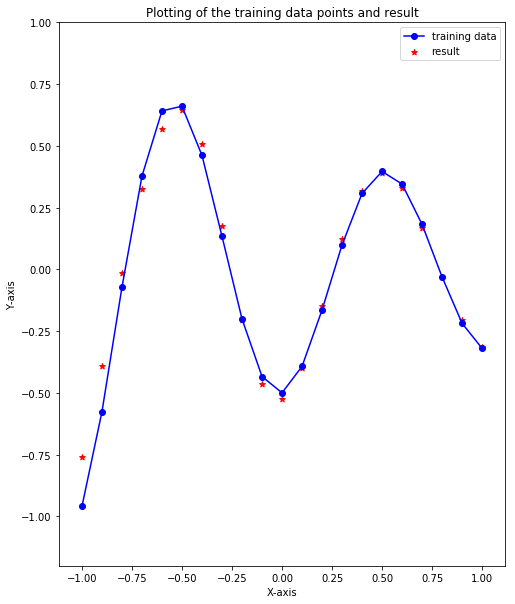

In [77]:
import matplotlib.pyplot as plt

show_result = result.reshape(21,1)

plt.figure(figsize=(8,10))
plt.plot(inputs,T,label = 'training data',marker='o',color ='blue')
plt.scatter(inputs,result,label = 'result',marker='*',color = 'red')
plt.title('Plotting of the training data points and result')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.ylim(-1.2,1)
plt.legend()
plt.show()

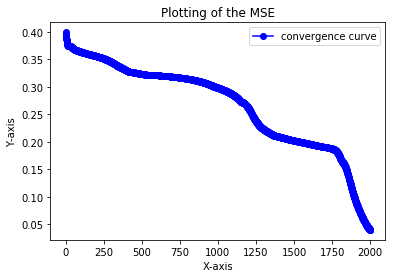

In [96]:
# To show the convergence curve, or 
# the variation of MSE during iterations

plt.plot(np.arange(0,len(convergence)),
         convergence,label = 'convergence curve',
         marker='o',color ='blue')

plt.title('Plotting of the MSE')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.show()


In [98]:
# What are the "results" from training ?
# 
print ('v = ', v)
print ('w = ', w)
print ('thres_b = ', thres_b)
print ('thres_c = ', thres_c)

v =  [[6.83086836 7.37993909 3.75844048 2.46369124 7.64386298]]
w =  [[-1.62825522]
 [ 1.65276462]
 [ 4.37760262]
 [ 0.94035243]
 [-3.17025827]]
thres_b =  [[-5.04059715 -1.55430492  3.03021211 -2.72894328  2.21488648]]
thres_c =  [[-2.17689899]]
